# Análisis Exploratorio de Datos (EDA) - Airbnb Mexico


## Objetivo
Entender la estructura, calidad y características de los datos antes de realizar transformaciones.

**Colecciones a analizar:**
- `Listings`: Información detallada de los apartamentos
- `Reviews`: Información de reseñas de clientes
- `Calendar`: Información de disponibilidad

## Importaciones

In [1]:
import sys
from pathlib import Path

# Raíz del proyecto: sirve si el cwd es `notebooks/` o la raíz del repo
_cwd = Path.cwd().resolve()
if (_cwd / "src").is_dir():
    _root = _cwd
elif (_cwd.parent / "src").is_dir():
    _root = _cwd.parent
else:
    _root = _cwd.parent
sys.path.insert(0, str(_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import Extraccion, get_logger

# Configuración de visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

logger = get_logger(__name__)
print("✓ Importaciones completadas")

✓ Importaciones completadas


## Funciones comunes

In [2]:
from src.eda import (
    analizar_campo_price,
    analizar_valores_negativos,
    analizar_estructura,
    analizar_valores_nulos,
    analizar_duplicados,
    analizar_outliers,
)

print('✓ Funciones EDA importadas desde src.eda (parametros compartidos con transformacion.py)')



✓ Funciones EDA importadas desde src.eda (parametros compartidos con transformacion.py)


## Extracción de datos desde MongoDB

In [3]:
# Conectar a MongoDB y extraer datos
extraccion = Extraccion()
print("Conectando a MongoDB...")
extraccion.conectar()

print("\nExtrayendo colecciones...")
df_listings = extraccion.extraer_coleccion("Listings")
df_reviews = extraccion.extraer_coleccion("Reviews")
df_calendar = extraccion.extraer_coleccion("Calendar")

print("\nExtracción completada")
print(f"\nRESUMEN:")
print(f"   - Listings: {len(df_listings):,} registros, {len(df_listings.columns)} columnas")
print(f"   - Reviews: {len(df_reviews):,} registros, {len(df_reviews.columns)} columnas")
print(f"   - Calendar: {len(df_calendar):,} registros, {len(df_calendar.columns)} columnas")

2026-04-13 00:26:29,550 | INFO | Extraccion | Conexion exitosa a MongoDB. Base de datos seleccionada: arbnb_MXN


Conectando a MongoDB...

Extrayendo colecciones...


2026-04-13 00:26:29,758 | INFO | Extraccion | Coleccion Listings extraida correctamente. Registros encontrados: 27051. Registros cargados en DataFrame: 27051.
2026-04-13 00:26:34,607 | INFO | Extraccion | Coleccion Reviews extraida correctamente. Registros encontrados: 1454740. Registros cargados en DataFrame: 1454740.
2026-04-13 00:27:17,341 | INFO | Extraccion | Coleccion Calendar extraida correctamente. Registros encontrados: 9873624. Registros cargados en DataFrame: 9873624.



Extracción completada

RESUMEN:
   - Listings: 27,051 registros, 17 columnas
   - Reviews: 1,454,740 registros, 3 columnas
   - Calendar: 9,873,624 registros, 6 columnas


## 1. Análisis de Colección: LISTINGS

Información detallada sobre los apartamentos disponibles en Airbnb Buenos Aires.

### Análisis de estructura

In [4]:
analizar_estructura(df_listings, "LISTINGS")


COLECCIÓN: LISTINGS

PRIMERAS FILAS (primeros 5 registros):


,_id,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review,reviews_per_month
0,69dbd58adcaeaf06fe6ef9f8,35797,Villa Dante,153786,Dici,Cuajimalpa de Morelos,19.38283,-99.27178,Entire home/apt,3673.0,1,0,1,363,0,NaT,NaN
1,69dbd58adcaeaf06fe6ef9f9,44616,Condesa Haus,196253,Fernando,Cuauhtémoc,19.41162,-99.17794,Entire home/apt,18000.0,1,65,9,360,1,2025-01-01,0.38
2,69dbd58adcaeaf06fe6ef9fa,56074,Great space in historical San Rafael,265650,Maris,Cuauhtémoc,19.43977,-99.15605,Entire home/apt,591.0,15,84,1,333,1,2025-02-27,0.48
3,69dbd58adcaeaf06fe6ef9fb,67703,"2 bedroom apt. deco bldg, Condesa",334451,Nicholas,Cuauhtémoc,19.41152,-99.16857,Entire home/apt,NaN,2,50,2,252,1,2024-10-30,0.30
4,69dbd58adcaeaf06fe6ef9fc,70644,Beautiful light Studio Coyoacan- full equipped !,212109,Trisha,Coyoacán,19.35448,-99.16217,Entire home/apt,NaN,3,134,3,234,8,2025-08-18,0.81



DIMENSIONES:
   - Filas: 27,051
   - Columnas: 17

TIPOS DE DATOS:
INFO
<class 'pandas.DataFrame'>
RangeIndex: 27051 entries, 0 to 27050
Columns: 17 entries, _id to reviews_per_month
dtypes: datetime64[us](1), float64(4), int64(7), object(2), str(3)
memory usage: 3.5+ MB
TYPES
_id                                          str
id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood                                str
latitude                                 float64
longitude                                float64
room_type                                    str
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm              

,count,mean,min,25%,50%,75%,max,std
id,27051.0,700355582609886464.0,35797.0,44104725.0,830736761677326976.0,1217382011952653056.0,1518561444972990720.0,570271415889610304.0
host_id,27051.0,242943885.020554,7365.0,56214432.0,176683531.0,428882972.0,720844507.0,206257879.87984
latitude,27051.0,19.40549,19.177848,19.392489,19.41539,19.432015,19.56101,0.04239
longitude,27051.0,-99.165385,-99.33963,-99.178499,-99.1671,-99.153731,-98.96336,0.033535
price,23567.0,1792.540841,61.0,643.0,1039.0,1611.0,900000.0,13230.940558
minimum_nights,27051.0,4.580866,1.0,1.0,2.0,2.0,1125.0,24.784605
number_of_reviews,27051.0,53.777679,0.0,4.0,21.0,69.0,1434.0,85.143043
calculated_host_listings_count,27051.0,14.559868,1.0,1.0,3.0,11.0,221.0,31.892178
availability_365,27051.0,232.686333,0.0,140.0,269.0,341.0,365.0,122.270858
number_of_reviews_ltm,27051.0,15.691028,0.0,0.0,7.0,23.0,665.0,23.615517



ESTADÍSTICAS COMPLETAS (incluye variables categóricas):


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
_id,27051,27051,69dbd58adcaeaf06fe6ef9f8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,27051.0,NaN,NaN,NaN,700355582609886464.0,35797.0,44104725.0,830736761677326976.0,1217382011952653056.0,1518561444972990720.0,570271415889610304.0
name,27051,25638,"Blueground | Roma Sur 1 recamara, AC & rooftop",52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,27051.0,NaN,NaN,NaN,242943885.020554,7365.0,56214432.0,176683531.0,428882972.0,720844507.0,206257879.87984
host_name,27045,4299,Alejandro,388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,27051,16,Cuauhtémoc,12514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,27051.0,NaN,NaN,NaN,19.40549,19.177848,19.392489,19.41539,19.432015,19.56101,0.04239
longitude,27051.0,NaN,NaN,NaN,-99.165385,-99.33963,-99.178499,-99.1671,-99.153731,-98.96336,0.033535
room_type,27051,4,Entire home/apt,17713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,23567.0,NaN,NaN,NaN,1792.540841,61.0,643.0,1039.0,1611.0,900000.0,13230.940558



COLUMNAS NO NUMÉRICAS (6):
   - _id: 27051 valores únicos
      Principales valores:
{'69dbd58adcaeaf06fe6ef9f8': 1, '69dbd58adcaeaf06fe6ef9f9': 1, '69dbd58adcaeaf06fe6ef9fa': 1, '69dbd58adcaeaf06fe6ef9fb': 1, '69dbd58adcaeaf06fe6ef9fc': 1}
   - name: 25638 valores únicos
      Principales valores:
{'Blueground | Roma Sur 1 recamara, AC & rooftop': 52, 'Perfecto Loft en gran ubicación': 48, 'Blueground | Polanco, Luxury Apartment': 37, 'Blueground | Amueblado, Security & Business Center': 33, 'Casa Miravalle | Condesa': 21}
   - host_name: 4300 valores únicos
      Principales valores:
{'Alejandro': 388, 'Alejandra': 322, 'Raul': 274, 'Luis': 269, 'Francisco': 235}
   - neighbourhood: 16 valores únicos
      Principales valores:
{'Cuauhtémoc': 12514, 'Miguel Hidalgo': 4573, 'Benito Juárez': 3087, 'Coyoacán': 1727, 'Álvaro Obregón': 978}
   - room_type: 4 valores únicos
      Principales valores:
{'Entire home/apt': 17713, 'Private room': 8995, 'Shared room': 257, 'Hotel room': 86}
   

### Interpretación del resultado

- La colección Listings (Anuncios) corresponde a los anuncios que la gente publica en las cuales promociona sus propiedad, habitaciones, experiencias, etc.
- La colección tiene la siguiente estructura: 
    - Filas: 27.051
    - Columnas: 17

*Explicación de sus campos*
- **id**  
  Identificador único del listing en Airbnb.

- **name**  
  Nombre del alojamiento.

- **host_id**  
  Identificador único del anfitrión.

- **host_name**  
  Nombre del anfitrión.

- **neighbourhood**  
  Barrio o zona donde se encuentra el alojamiento.

- **latitude**  
  Latitud geográfica.

- **longitude**  
  Longitud geográfica.

- **room_type**  
  Tipo de propiedad:
  - `Entire home/apt`: alojamiento completo
  - `Private room`: habitación privada
  - `Shared room`: habitación compartida

- **minimum_nights**  
  Número mínimo de noches requeridas por reserva.

- **price**  
  Precio por noche (en MXN).

- **number_of_reviews**  
  Número total de reseñas recibidas.

- **last_review**  
  Fecha de la última reseña.

- **reviews_per_month**  
  Promedio de reseñas por mes.

- **number_of_reviews_ltm**  
  Número de reseñas en los últimos 12 meses.

- **calculated_host_listings_count**  
  Número de propiedades que tiene el anfitrión.

- **availability_365**  
  Número de días en el año en los que el alojamiento está disponible.

### Interpretación general

Este dataset permite analizar:
- Oferta de alojamientos
- Precios por zona
- Actividad y demanda (reseñas)
- Tipo de anfitriones (casuales vs profesionales)
- Disponibilidad anual




### Análisis de valores nulos

In [5]:
analizar_valores_nulos(df_listings, "LISTINGS")

# Coherencia last_review vs reviews_per_month (mismos nulos)
_mask = df_listings["last_review"].isna() | df_listings["reviews_per_month"].isna()
print("\nMUESTRA: last_review o reviews_per_month nulos (head 15)")
display(df_listings.loc[_mask].head(15))

_lr = df_listings["last_review"].isna()
_rpm = df_listings["reviews_per_month"].isna()
print("\nTabla de contingencia (filas nulas en cada columna):")
display(pd.crosstab(_lr, _rpm, rownames=["last_review_nulo"], colnames=["reviews_per_month_nulo"]))

ambos_igual = (_lr == _rpm).all()
solo_lr = int((_lr & ~_rpm).sum())
solo_rpm = int((~_lr & _rpm).sum())
print(f"\n¿Siempre coinciden los nulos? {ambos_igual}")
if not ambos_igual:
    print(f"   Filas con solo last_review nulo: {solo_lr}")
    print(f"   Filas con solo reviews_per_month nulo: {solo_rpm}")



VALORES NULOS Y FALTANTES - LISTINGS:
--------------------------------------------------------------------------------
   Columnas con valores faltantes:


,Columna,Cantidad de nulos,Porcentaje (%)
9,price,3484,12.88
15,last_review,3401,12.57
16,reviews_per_month,3401,12.57
4,host_name,6,0.02



MUESTRA: last_review o reviews_per_month nulos (head 15)


,_id,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review,reviews_per_month
0,69dbd58adcaeaf06fe6ef9f8,35797,Villa Dante,153786,Dici,Cuajimalpa de Morelos,19.38283,-99.27178,Entire home/apt,3673.0,1,0,1,363,0,NaT,NaN
5,69dbd58adcaeaf06fe6ef9fd,131610,MARIA DEL ALMA,647454,Fernando,Coyoacán,19.35416,-99.16488,Private room,NaN,1,0,3,0,0,NaT,NaN
18,69dbd58adcaeaf06fe6efa0a,276504,High End Condo with golf package,1444589,Michael,Iztacalco,19.38061,-99.12729,Entire home/apt,NaN,7,0,1,0,0,NaT,NaN
21,69dbd58adcaeaf06fe6efa0d,291804,A nice room with great location,1511568,Luis Ernesto,Benito Juárez,19.36305,-99.15412,Private room,NaN,2,0,1,0,0,NaT,NaN
27,69dbd58adcaeaf06fe6efa13,331030,"Rento Recámara, Baño privado, Coyoacán Conchita",1688597,Emma,Coyoacán,19.34549,-99.15872,Private room,1310.0,2,0,2,363,0,NaT,NaN
28,69dbd58adcaeaf06fe6efa14,350079,beautiful furnished room Rome area,1773936,Elizabeth,Cuauhtémoc,19.40639,-99.16686,Private room,NaN,5,0,1,0,0,NaT,NaN
49,69dbd58adcaeaf06fe6efa29,642725,Recamara en depa a 5 minutos del metropolitano,3213044,Laura,Cuauhtémoc,19.40809,-99.18109,Private room,NaN,2,0,1,0,0,NaT,NaN
100,69dbd58adcaeaf06fe6efa5c,1656382,Habitación individual c baño propio,796221,Karla,Cuauhtémoc,19.41095,-99.18215,Private room,NaN,1,0,1,0,0,NaT,NaN
145,69dbd58adcaeaf06fe6efa89,2516668,Room in new apartment of 1250ft²,3729922,Pedro,Benito Juárez,19.39507,-99.15226,Private room,NaN,30,0,1,0,0,NaT,NaN
158,69dbd58adcaeaf06fe6efa96,2716028,Reforma a la puerta,2333285,Maria Luisa Hilda,Cuauhtémoc,19.42423,-99.16917,Private room,5509.0,1,0,1,365,0,NaT,NaN



Tabla de contingencia (filas nulas en cada columna):


reviews_per_month_nulo,False,True
last_review_nulo,,
False,23650,0
True,0,3401



¿Siempre coinciden los nulos? True


### Formato de `price` y valores negativos

Antes de transformar, se revisa si `price` llega como texto con símbolos o separadores inconsistentes, y si hay columnas numéricas con valores negativos inesperados.

In [6]:
res_price = analizar_campo_price(df_listings, col="price", nombre_coleccion="LISTINGS")
res_neg = analizar_valores_negativos(
    df_listings,
    columnas=["price", "minimum_nights", "number_of_reviews", "calculated_host_listings_count", "availability_365", "number_of_reviews_ltm"],
    nombre_coleccion="LISTINGS",
)


ANÁLISIS DE CAMPO `price` - LISTINGS
--------------------------------------------------------------------------------
   Tipo pandas: float64
   Registros: 27,051 | Nulos: 3,484 (12.88%)

   pd.to_numeric(errors='coerce'):
      - Reconocidos como número: 23,567
      - No nulos que NO convierten: 0

   Formato de la representación en texto (no nulos):


,conteo
price,
punto_como_decimal,23567


   Filas con símbolo $ € £ ¥ ¢ en el texto: 0

   Estadísticos si se interpretan como número:
      - Mín: 61.0 | Máx: 900000.0 | Media: 1792.54

   Nota: la columna ya es numérica; el análisis de 'formato texto' aplica al castear a string.

VALORES NEGATIVOS - LISTINGS
--------------------------------------------------------------------------------

   Columna: price
      - Numéricos válidos: 23,567 | No nulos no convertibles: 0
      - Negativos: 0 | Ceros: 0 | Positivos: 23,567
      - Mínimo: 61.0 | Máximo: 900000.0
      >>> Sin valores negativos en valores numéricos válidos.

   Columna: minimum_nights
      - Numéricos válidos: 27,051 | No nulos no convertibles: 0
      - Negativos: 0 | Ceros: 0 | Positivos: 27,051
      - Mínimo: 1 | Máximo: 1125
      >>> Sin valores negativos en valores numéricos válidos.

   Columna: number_of_reviews
      - Numéricos válidos: 27,051 | No nulos no convertibles: 0
      - Negativos: 0 | Ceros: 3,401 | Positivos: 23,650
      - Mínimo: 0 | M

### Interpretación del resultado

- Las filas cuyo price sea nulo, deben de ser descartadas ya que el precio no es un valor que se pueda inferir o calcular con base en otros datos. Es un valor que el anfitrión asigna a su propiedad con base en su criterio
- Dado que last_review y reviews_per_month tienen el mismo número de nulos, se realiza un análisis para comprobar que si uno de los valores es nulo el otro también. Siendo esto algo real.

Para este caso lo que haremos será obtener estos valores desde la colección de Reviews:
- Relacionando vía Listing_id, obtendremos:
- La fecha de la ultima Review
- El promedio de Reviews por mes

En caso de que luego de esto, hayan filas en donde el valor de last_review o de reviews_per_month sea nulo. Estás filas serán eliminadas

- Para los host_names sin valor, se asignará el valor de "empty_hostname" para agruparlos de mejor manera

### Análisis de duplicados

In [7]:
analizar_duplicados(df_listings, "LISTINGS", col_id='id')


REGISTROS DUPLICADOS - LISTINGS:
--------------------------------------------------------------------------------
   1. POR COLUMNA ID (id):
      - Total de registros: 27,051
      - Registros únicos: 27,051
      - Duplicados por ID: 0 (0.00%)

   2. FILAS COMPLETAMENTE DUPLICADAS (todas las columnas):
      - Filas duplicadas: 0 (0.00%)

   Excelente: No hay duplicados en esta colección


### Análisis de outliers

In [8]:
analizar_outliers(df_listings, "LISTINGS", columnas=["price", "minimum_nights", "availability_365"])


ANÁLISIS DE OUTLIERS - LISTINGS:
--------------------------------------------------------------------------------

   price:
      - Mínimo: 61.00
      - Q1 (25%): 643.00
      - Mediana: 1039.00
      - Q3 (75%): 1611.00
      - Máximo: 900000.00
      - IQR: 968.00
      - Outliers detectados: 1,768 (7.50%)
      - Rango válido: [-809.00, 3063.00]

   minimum_nights:
      - Mínimo: 1.00
      - Q1 (25%): 1.00
      - Mediana: 2.00
      - Q3 (75%): 2.00
      - Máximo: 1125.00
      - IQR: 1.00
      - Outliers detectados: 3,429 (12.68%)
      - Rango válido: [-0.50, 3.50]

   availability_365:
      - Mínimo: 0.00
      - Q1 (25%): 140.00
      - Mediana: 269.00
      - Q3 (75%): 341.00
      - Máximo: 365.00
      - IQR: 201.00
      - Outliers detectados: 0 (0.00%)
      - Rango válido: [-161.50, 642.50]


### Interpretación del resultado

El resultado del análisis estádistico y de outliers, permite o nos da la opción de crear categorias para poder clasificar los listings.

### 1. price → Categoría de precio

**Estadísticos:**
- Q1: 643
- Mediana: 1039
- Q3: 1611
- Límite superior (sin outliers): 3063

**Nueva variable: `price_category`**

- Budget         → price ≤ 643
- Mid-range      → 643 < price ≤ 1039
- Upper-mid      → 1039 < price ≤ 1611
- Premium        → 1611 < price ≤ 3063
- Luxury/Outlier → price > 3063

---

### 2. minimum_nights → Tipo de estancia

**Estadísticos:**
- Q1: 1
- Mediana: 2
- Q3: 2
- Límite superior (sin outliers): 3.5

**Nueva variable: `stay_category`**

- Short stay     → minimum_nights ≤ 1
- Standard stay  → 1 < minimum_nights ≤ 2
- Extended stay  → 2 < minimum_nights ≤ 3
- Long stay/outlier → minimum_nights > 3

---

### 3. availability_365 → Nivel de disponibilidad

**Estadísticos:**
- Q1: 140
- Mediana: 269
- Q3: 341
- Sin outliers detectados

**Nueva variable: `availability_category`**

- Low availability    → availability_365 ≤ 140
- Medium availability → 140 < availability_365 ≤ 269
- High availability   → 269 < availability_365 ≤ 341
- Very high availability → availability_365 > 341

---

### Notas metodológicas

- Se utilizó el criterio de IQR (Interquartile Range) para detectar outliers.
- Las categorías se definieron con base en cuantiles para mantener balance en la distribución.
- Los valores fuera del rango superior se consideran "outliers" pero se mantienen como categoría separada para análisis.




## 2. Análisis de Colección: REVIEWS

Información sobre las reseñas que dejan los usuarios de los apartamentos.

### Análisis de estructura

In [9]:
analizar_estructura(df_reviews, "REVIEWS")


COLECCIÓN: REVIEWS

PRIMERAS FILAS (primeros 5 registros):


,_id,listing_id,date
0,69dbd860dcaeaf06fe060c7e,44616,2011-11-09
1,69dbd860dcaeaf06fe060c7f,44616,2012-08-16
2,69dbd860dcaeaf06fe060c80,44616,2012-12-28
3,69dbd860dcaeaf06fe060c81,44616,2013-01-04
4,69dbd860dcaeaf06fe060c82,44616,2013-03-19



DIMENSIONES:
   - Filas: 1,454,740
   - Columnas: 3

TIPOS DE DATOS:
INFO
<class 'pandas.DataFrame'>
RangeIndex: 1454740 entries, 0 to 1454739
Columns: 3 entries, _id to date
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 33.3 MB
TYPES
_id                      str
listing_id             int64
date          datetime64[us]
dtype: object

ESTADÍSTICAS (Columnas numéricas):


,count,mean,min,25%,50%,75%,max,std
listing_id,1454740.0,355821508552638016.0,44616.0,26850859.0,46919861.0,791170307741018368.0,1517372885452894720.0,471299866764997760.0
date,1454740,2023-02-18 02:05:34.001128,2011-04-02 00:00:00,2022-02-02 00:00:00,2023-10-17 00:00:00,2024-11-18 00:00:00,2025-09-28 00:00:00,NaN



ESTADÍSTICAS COMPLETAS (incluye variables categóricas):


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
_id,1454740,1454740,69dbd860dcaeaf06fe060c7e,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_id,1454740.0,NaN,NaN,NaN,355821508552638016.0,44616.0,26850859.0,46919861.0,791170307741018368.0,1517372885452894720.0,471299866764997760.0
date,1454740,NaN,NaN,NaN,2023-02-18 02:05:34.001128,2011-04-02 00:00:00,2022-02-02 00:00:00,2023-10-17 00:00:00,2024-11-18 00:00:00,2025-09-28 00:00:00,NaN



COLUMNAS NO NUMÉRICAS (2):
   - _id: 1454740 valores únicos
      Principales valores:
{'69dbd860dcaeaf06fe060c7e': 1, '69dbd860dcaeaf06fe060c7f': 1, '69dbd860dcaeaf06fe060c80': 1, '69dbd860dcaeaf06fe060c81': 1, '69dbd860dcaeaf06fe060c82': 1}
   - date: 4754 valores únicos
      Principales valores:
{Timestamp('2025-08-31 00:00:00'): 2753, Timestamp('2025-06-29 00:00:00'): 2657, Timestamp('2025-03-17 00:00:00'): 2542, Timestamp('2025-04-27 00:00:00'): 2520, Timestamp('2025-02-24 00:00:00'): 2510}


### Interpretación del resultado

- La colección Reviews (Reseñas) corresponde a las opiniones de la gente acerca del servicio obtenido
- La colección tiene la siguiente estructura: 
    - Filas: 1.454.740
    - Columnas: 3

*Explicación de sus campos*
- **_id (ObjectId)**  
  Identificador único del documento en MongoDB.  
  No tiene valor analítico directo.

- **listing_id (Int32)**  
  Identificador del alojamiento al que pertenece la reseña.  
  Permite relacionar esta colección con `Listings` y `Calendar`.

- **date (Date)**  
  Fecha en la que se realizó la reseña.  
  Es clave para análisis de tendencia, estacionalidad y actividad en el tiempo.

**Consideraciones**

- No todas las reservas generan una reseña → los datos pueden subestimar la demanda real
- No incluye contenido textual de la reseña (solo metadata)
- Puede haber sesgo hacia usuarios más activos o experiencias extremas

### Análisis de valores nulos

In [10]:
analizar_valores_nulos(df_reviews, "REVIEWS")


VALORES NULOS Y FALTANTES - REVIEWS:
--------------------------------------------------------------------------------
   Todas las columnas están completas (sin nulos)


### Análisis de duplicados

In [11]:
analizar_duplicados(df_reviews, "REVIEWS", col_id='_id')


REGISTROS DUPLICADOS - REVIEWS:
--------------------------------------------------------------------------------
   1. POR COLUMNA ID (_id):
      - Total de registros: 1,454,740
      - Registros únicos: 1,454,740
      - Duplicados por ID: 0 (0.00%)

   2. FILAS COMPLETAMENTE DUPLICADAS (todas las columnas):
      - Filas duplicadas: 0 (0.00%)

   Excelente: No hay duplicados en esta colección


### Análisis de outliers

In [12]:
analizar_outliers(df_reviews, "REVIEWS")


ANÁLISIS DE OUTLIERS - REVIEWS:
--------------------------------------------------------------------------------

   listing_id:
      - Mínimo: 44616.00
      - Q1 (25%): 26850859.00
      - Mediana: 46919861.00
      - Q3 (75%): 791170307741018368.00
      - Máximo: 1517372885452894720.00
      - IQR: 791170307714167552.00
      - Outliers detectados: 0 (0.00%)
      - Rango válido: [-1186755461544400384.00, 1977925769312269568.00]


## 3. Análisis de Colección: CALENDAR

Información sobre disponibilidad, precios y políticas de noches mínimas para cada día.

### Análisis de estructura

In [13]:
analizar_estructura(df_calendar, "CALENDAR")


COLECCIÓN: CALENDAR

PRIMERAS FILAS (primeros 5 registros):


,_id,listing_id,date,available,minimum_nights,maximum_nights
0,69dbd65cdcaeaf06fe6f63a4,7860479,2025-09-28,False,5,28
1,69dbd65cdcaeaf06fe6f63a5,7860479,2025-09-29,False,5,28
2,69dbd65cdcaeaf06fe6f63a6,7860479,2025-09-30,False,5,28
3,69dbd65cdcaeaf06fe6f63a7,7860479,2025-10-01,False,5,28
4,69dbd65cdcaeaf06fe6f63a8,7860479,2025-10-02,False,5,28



DIMENSIONES:
   - Filas: 9,873,624
   - Columnas: 6

TIPOS DE DATOS:
INFO
<class 'pandas.DataFrame'>
RangeIndex: 9873624 entries, 0 to 9873623
Columns: 6 entries, _id to maximum_nights
dtypes: bool(1), datetime64[us](1), int64(3), str(1)
memory usage: 386.1 MB
TYPES
_id                          str
listing_id                 int64
date              datetime64[us]
available                   bool
minimum_nights             int64
maximum_nights             int64
dtype: object

ESTADÍSTICAS (Columnas numéricas):


,count,mean,min,25%,50%,75%,max,std
listing_id,9873624.0,700355870257449216.0,35797.0,44104681.0,830736761677326976.0,1217411034178283008.0,1518561444972990720.0,570260905803648384.0
date,9873624,2026-03-28 17:33:26.990745,2025-09-27 00:00:00,2025-12-27 00:00:00,2026-03-29 00:00:00,2026-06-28 00:00:00,2026-09-27 00:00:00,NaN
minimum_nights,9873624.0,4.309379,1.0,1.0,2.0,2.0,1125.0,23.623162
maximum_nights,9873624.0,794562.366399,1.0,365.0,730.0,1125.0,2147483647.0,41281702.330175



ESTADÍSTICAS COMPLETAS (incluye variables categóricas):


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
_id,9873624,9873624,69dbd65cdcaeaf06fe6f63a4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_id,9873624.0,NaN,NaN,NaN,700355870257449216.0,35797.0,44104681.0,830736761677326976.0,1217411034178283008.0,1518561444972990720.0,570260905803648384.0
date,9873624,NaN,NaN,NaN,2026-03-28 17:33:26.990745,2025-09-27 00:00:00,2025-12-27 00:00:00,2026-03-29 00:00:00,2026-06-28 00:00:00,2026-09-27 00:00:00,NaN
available,9873624,2,True,6299554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minimum_nights,9873624.0,NaN,NaN,NaN,4.309379,1.0,1.0,2.0,2.0,1125.0,23.623162
maximum_nights,9873624.0,NaN,NaN,NaN,794562.366399,1.0,365.0,730.0,1125.0,2147483647.0,41281702.330175



COLUMNAS NO NUMÉRICAS (3):
   - _id: 9873624 valores únicos
      Principales valores:
{'69dbd65cdcaeaf06fe6f63a4': 1, '69dbd65cdcaeaf06fe6f63a5': 1, '69dbd65cdcaeaf06fe6f63a6': 1, '69dbd65cdcaeaf06fe6f63a7': 1, '69dbd65cdcaeaf06fe6f63a8': 1}
   - date: 366 valores únicos
      Principales valores:
{Timestamp('2025-09-28 00:00:00'): 27051, Timestamp('2025-09-29 00:00:00'): 27051, Timestamp('2025-09-30 00:00:00'): 27051, Timestamp('2025-10-01 00:00:00'): 27051, Timestamp('2025-10-02 00:00:00'): 27051}
   - available: 2 valores únicos
      Principales valores:
{True: 6299554, False: 3574070}


### Interpretación del resultado

- La colección Calendar (Calendario) corresponde a la disponibilidad diaria de un alojamiento. Cada fila es un día específico de una propiedad
- La colección tiene la siguiente estructura: 
    - Filas: 9,873,624
    - Columnas: 6

*Explicación de sus campos*
- **_id (ObjectId)**  
  Identificador único del documento en MongoDB.  
  No tiene valor analítico directo.

- **listing_id (Int32)**  
  Identificador del alojamiento.  
  Permite relacionar esta colección con `Listings`.

- **date (Date)**  
  Fecha específica del calendario.  
  Cada registro corresponde a un día para un alojamiento.

- **available (Boolean)**  
  Indica si el alojamiento está disponible en esa fecha:
  - `true` → disponible para reservar  
  - `false` → no disponible (reservado o bloqueado)

- **minimum_nights (Int32)**  
  Número mínimo de noches requeridas para reservar en esa fecha.

- **maximum_nights (Int32)**  
  Número máximo de noches permitidas para una reserva.

**Consideraciones**

- `available = false` no siempre implica reserva (puede ser bloqueo manual del host)
- Requiere agregación para análisis (datos están a nivel diario)
- Puede ser voluminoso (una fila por día por propiedad)

### Interpretación general

Este dataset permite analizar la **disponibilidad y ocupación diaria de los alojamientos**, ya que:

- Cada fila representa un día específico
- Permite construir el calendario completo de cada propiedad

### Análisis de valores nulos

In [14]:
analizar_valores_nulos(df_calendar, "CALENDAR")


VALORES NULOS Y FALTANTES - CALENDAR:
--------------------------------------------------------------------------------
   Todas las columnas están completas (sin nulos)


### Análisis de duplicados

In [15]:
analizar_duplicados(df_calendar, "CALENDAR", col_id='_id')


REGISTROS DUPLICADOS - CALENDAR:
--------------------------------------------------------------------------------
   1. POR COLUMNA ID (_id):
      - Total de registros: 9,873,624
      - Registros únicos: 9,873,624
      - Duplicados por ID: 0 (0.00%)

   2. FILAS COMPLETAMENTE DUPLICADAS (todas las columnas):
      - Filas duplicadas: 0 (0.00%)

   Excelente: No hay duplicados en esta colección


### Análisis de outliers

In [16]:
analizar_outliers(df_calendar, "CALENDAR", columnas=["maximum_nights", "minimum_nights"])


ANÁLISIS DE OUTLIERS - CALENDAR:
--------------------------------------------------------------------------------

   maximum_nights:
      - Mínimo: 1.00
      - Q1 (25%): 365.00
      - Mediana: 730.00
      - Q3 (75%): 1125.00
      - Máximo: 2147483647.00
      - IQR: 760.00
      - Outliers detectados: 7,280 (0.07%)
      - Rango válido: [-775.00, 2265.00]

   minimum_nights:
      - Mínimo: 1.00
      - Q1 (25%): 1.00
      - Mediana: 2.00
      - Q3 (75%): 2.00
      - Máximo: 1125.00
      - IQR: 1.00
      - Outliers detectados: 1,296,995 (13.14%)
      - Rango válido: [-0.50, 3.50]


### Análisis de valores negativos

In [17]:
analizar_valores_negativos(
    df_calendar,
    columnas=["minimum_nights", "maximum_nights"],
    nombre_coleccion="CALENDAR",
)



VALORES NEGATIVOS - CALENDAR
--------------------------------------------------------------------------------

   Columna: minimum_nights
      - Numéricos válidos: 9,873,624 | No nulos no convertibles: 0
      - Negativos: 0 | Ceros: 0 | Positivos: 9,873,624
      - Mínimo: 1 | Máximo: 1125
      >>> Sin valores negativos en valores numéricos válidos.

   Columna: maximum_nights
      - Numéricos válidos: 9,873,624 | No nulos no convertibles: 0
      - Negativos: 0 | Ceros: 0 | Positivos: 9,873,624
      - Mínimo: 1 | Máximo: 2147483647
      >>> Sin valores negativos en valores numéricos válidos.


{'minimum_nights': {'n_negativos': 0,
  'n_validos': 9873624,
  'min': 1.0,
  'max': 1125.0,
  'requiere_atencion': False},
 'maximum_nights': {'n_negativos': 0,
  'n_validos': 9873624,
  'min': 1.0,
  'max': 2147483647.0,
  'requiere_atencion': False}}

## 4. Visualizaciones y hallazgos principales

Las siguientes gráficas se construyen con variables alineadas con el taller y con mayor valor analático para inteligencia de negocios: `price`, `room_type`, `neighbourhood`, `minimum_nights`, fechas de `Reviews` y disponibilidad de `Calendar`.

### Preparación de datos para visualización

Para mejorar la legibilidad de algunas gráficas, se filtran valores nulos en `price`, se limita la visualización del precio al percentil 99 y se generan agregaciones mensuales para `Reviews` y `Calendar`.

In [18]:
df_listings_viz = df_listings.copy()

# Limpiar price porque en MongoDB puede venir como texto con simbolos y comas.
df_listings_viz['price_num'] = (
    df_listings_viz['price']
    .astype(str)
    .str.replace(r'[$,]', '', regex=True)
    .str.strip()
)
df_listings_viz['price_num'] = pd.to_numeric(df_listings_viz['price_num'], errors='coerce')
df_listings_viz['minimum_nights_num'] = pd.to_numeric(df_listings_viz['minimum_nights'], errors='coerce')
df_listings_viz['availability_365_num'] = pd.to_numeric(df_listings_viz['availability_365'], errors='coerce')
df_listings_viz['number_of_reviews_num'] = pd.to_numeric(df_listings_viz['number_of_reviews'], errors='coerce')

df_listings_viz = df_listings_viz.dropna(subset=['price_num', 'room_type'])

price_q99 = df_listings_viz['price_num'].quantile(0.99)
df_price_plot = df_listings_viz[df_listings_viz['price_num'] <= price_q99].copy()

top_neighbourhoods = df_listings['neighbourhood'].value_counts().head(10)
avg_price_by_room_type = (
    df_listings_viz.groupby('room_type', as_index=False)['price_num']
    .mean()
    .sort_values('price_num', ascending=False)
)

reviews_by_month = df_reviews['date'].dt.to_period('M').value_counts().sort_index()
reviews_by_month.index = reviews_by_month.index.to_timestamp()

availability_by_month = (
    df_calendar.groupby(df_calendar['date'].dt.to_period('M'))['available']
    .mean()
    .sort_index()
    * 100
)
availability_by_month.index = availability_by_month.index.to_timestamp()

stay_labels = ['Short stay', 'Standard stay', 'Extended stay', 'Long stay/outlier']
stay_category = pd.cut(
    pd.to_numeric(df_listings['minimum_nights'], errors='coerce'),
    bins=[-float('inf'), 1, 2, 3, float('inf')],
    labels=stay_labels
)
stay_counts = stay_category.value_counts().reindex(stay_labels)

print(f'Percentil 99 de price: {price_q99:,.0f}')
display(avg_price_by_room_type)
display(top_neighbourhoods.to_frame('listings'))

Percentil 99 de price: 9,919


,room_type,price_num
1,Hotel room,42841.000000
0,Entire home/apt,1930.279504
2,Private room,1226.560462
3,Shared room,360.885827


,listings
neighbourhood,
Cuauhtémoc,12514
Miguel Hidalgo,4573
Benito Juárez,3087
Coyoacán,1727
Álvaro Obregón,978
Venustiano Carranza,907
Tlalpan,806
Gustavo A. Madero,515
Iztacalco,482


### 4.1 Distribución del precio por noche

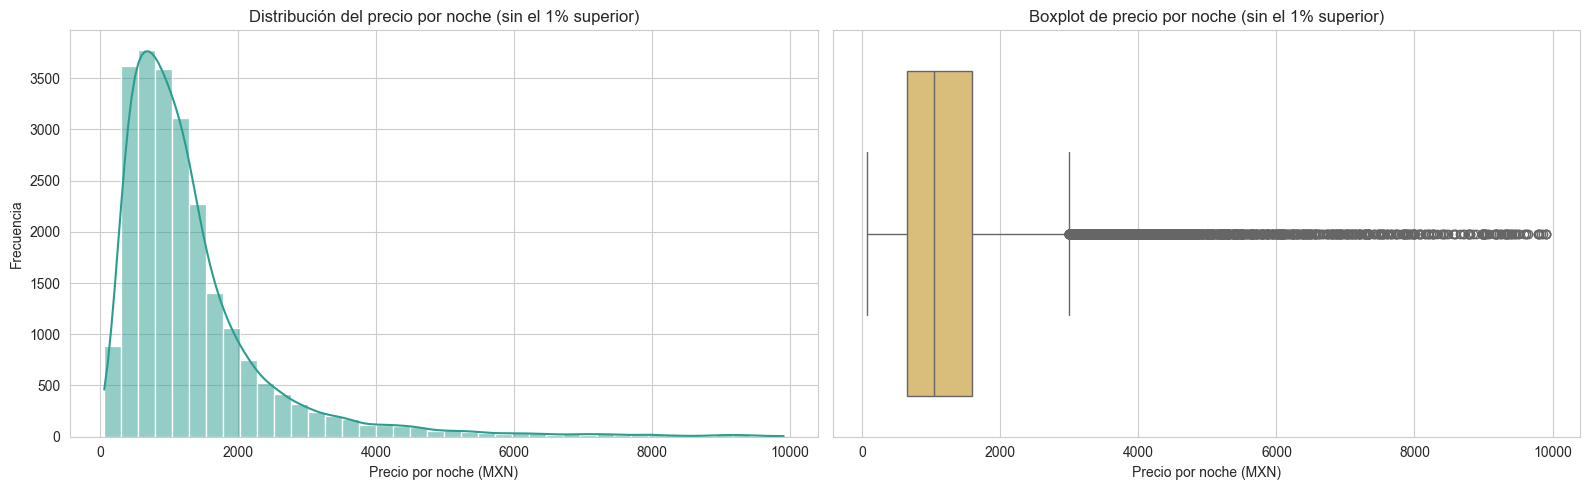

In [19]:
if df_price_plot.empty:
    print('No hay datos validos en price_num para graficar. Ejecuta primero la celda de preparacion.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(df_price_plot['price_num'], bins=40, kde=True, ax=axes[0], color='#2a9d8f')
    axes[0].set_title('Distribución del precio por noche (sin el 1% superior)')
    axes[0].set_xlabel('Precio por noche (MXN)')
    axes[0].set_ylabel('Frecuencia')

    sns.boxplot(x=df_price_plot['price_num'], ax=axes[1], color='#e9c46a')
    axes[1].set_title('Boxplot de precio por noche (sin el 1% superior)')
    axes[1].set_xlabel('Precio por noche (MXN)')

    plt.tight_layout()
    plt.show()

### Interpretación

La distribución del precio es claramente asimétrica hacia la derecha, lo que indica que la mayor parte de los alojamientos se concentra en rangos bajos y medios, mientras que existe un grupo más pequeño con precios muy altos. Esto coincide con el análisis de outliers realizado previamente y justifica la creación de categorías de precio para la fase de transformación. Desde inteligencia de negocios, esta gráfica permite identificar que el mercado no es homogéneo y que conviene segmentarlo por niveles de precio en lugar de analizarlo con un único promedio global.

### 4.2 Precio promedio por tipo de habitación

C:\Users\fel0o\AppData\Local\Temp\ipykernel_23136\3620005509.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=avg_price_by_room_type, x='room_type', y='price_num', palette='Set2')


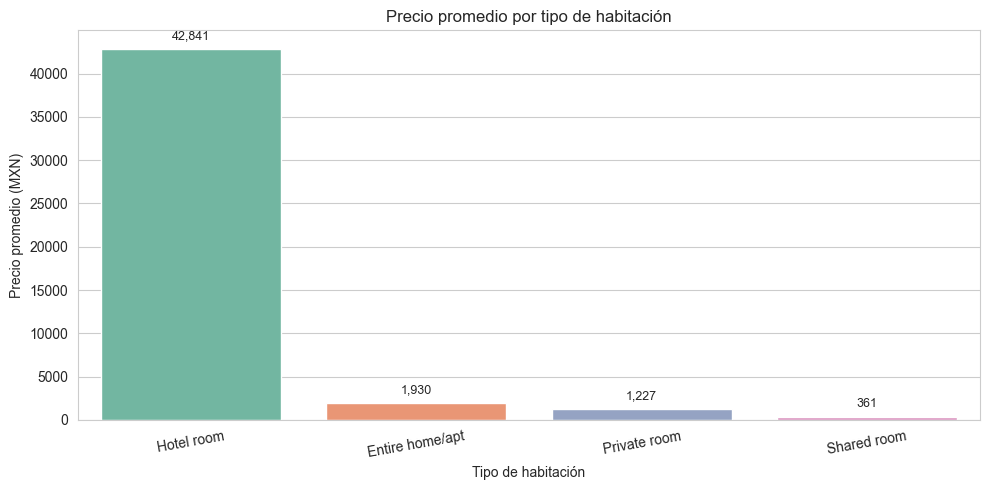

In [20]:
if avg_price_by_room_type.empty:
    print('No hay datos validos para calcular el precio promedio por tipo de habitación.')
else:
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=avg_price_by_room_type, x='room_type', y='price_num', palette='Set2')
    ax.set_title('Precio promedio por tipo de habitación')
    ax.set_xlabel('Tipo de habitación')
    ax.set_ylabel('Precio promedio (MXN)')
    plt.xticks(rotation=10)

    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f'{height:,.0f}',
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 5),
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()

### Interpretación

El precio promedio cambia de forma importante según el tipo de habitación. Este comportamiento muestra que `room_type` es una variable explicativa clave para segmentar la oferta y entender diferencias de valor dentro de la plataforma. Para el análisis de negocio, esta gráfica permite comparar rápidamente qué modalidad concentra los precios más altos y cuáles atienden segmentos más accesibles del mercado.

### 4.3 Top 10 barrios por cantidad de alojamientos

C:\Users\fel0o\AppData\Local\Temp\ipykernel_23136\776032846.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index, palette='Blues_r')


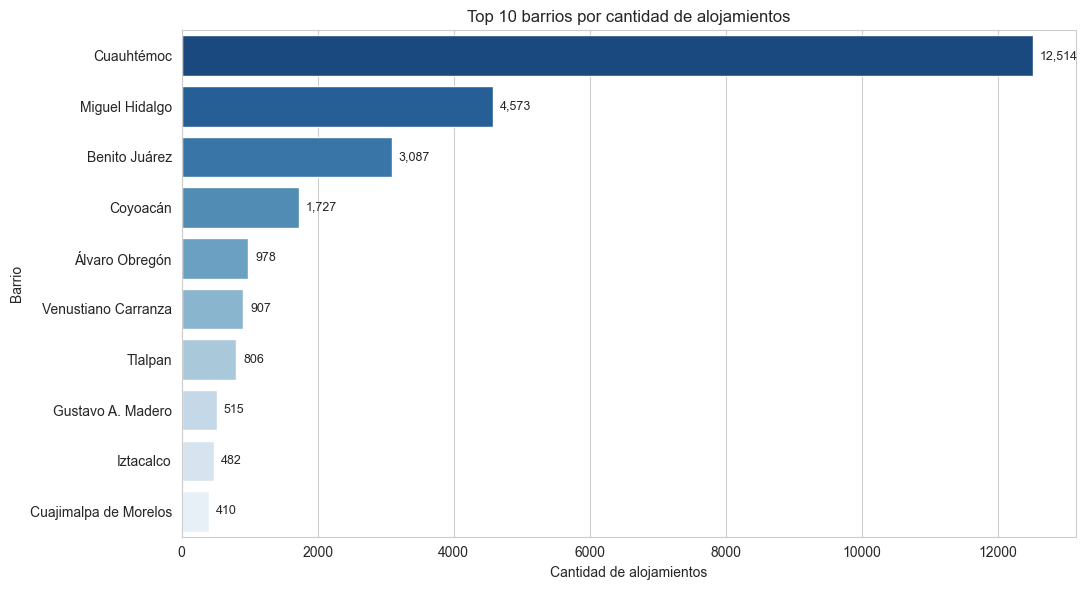

In [21]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index, palette='Blues_r')
ax.set_title('Top 10 barrios por cantidad de alojamientos')
ax.set_xlabel('Cantidad de alojamientos')
ax.set_ylabel('Barrio')

for patch in ax.patches:
    width = patch.get_width()
    ax.annotate(f'{int(width):,}',
                (width, patch.get_y() + patch.get_height() / 2),
                ha='left', va='center', fontsize=9, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Interpretación

La oferta de alojamientos no se distribuye de manera uniforme entre los barrios. Existen zonas con una concentración mucho mayor de anuncios, lo que sugiere polos de mayor actividad turística o comercial dentro de la ciudad. Esta visualización es útil para identificar mercados más competidos y también para contextualizar posteriores comparaciones de precio, reseñas y disponibilidad por zona.

### 4.4 Evolución mensual de reseñas

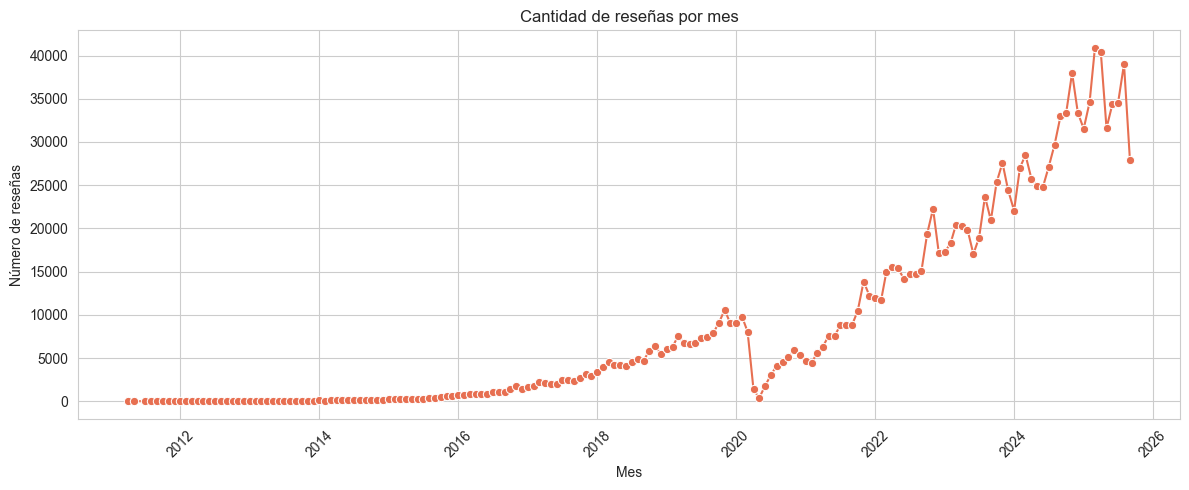

In [22]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=reviews_by_month.index, y=reviews_by_month.values, marker='o', color='#e76f51')
plt.title('Cantidad de reseñas por mes')
plt.xlabel('Mes')
plt.ylabel('Número de reseñas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación

La serie temporal de reseñas permite observar la dinámica de actividad en la plataforma a lo largo del tiempo. Los picos y caídas mensuales pueden asociarse con estacionalidad, periodos vacacionales o cambios en la demanda. En términos de inteligencia de negocios, esta gráfica ayuda a detectar meses de mayor interacción de usuarios y sirve como base para comparaciones posteriores con disponibilidad y ocupación.

### 4.5 Disponibilidad mensual promedio

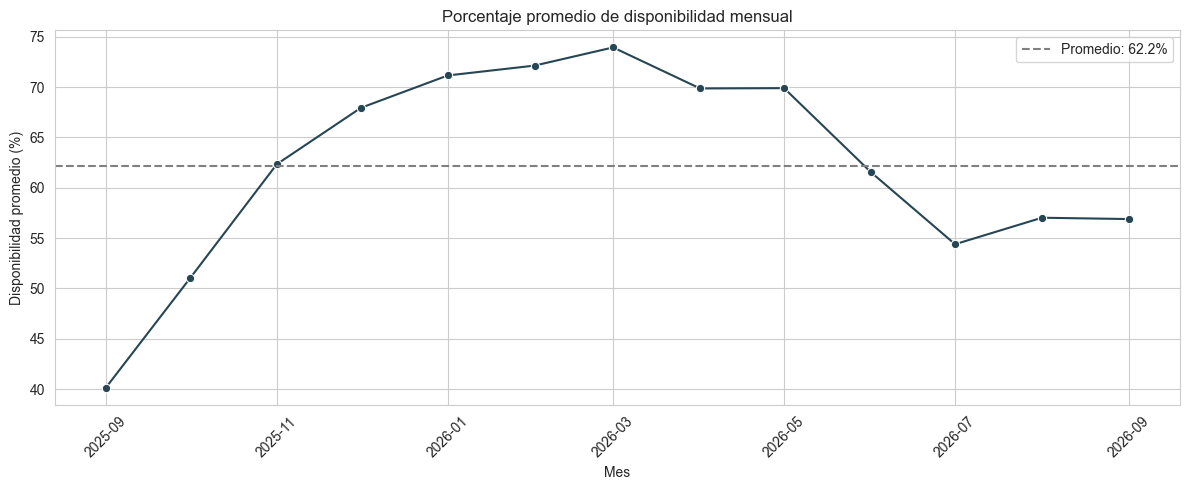

In [23]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=availability_by_month.index, y=availability_by_month.values, marker='o', color='#264653')
plt.axhline(availability_by_month.mean(), linestyle='--', color='gray', label=f'Promedio: {availability_by_month.mean():.1f}%')
plt.title('Porcentaje promedio de disponibilidad mensual')
plt.xlabel('Mes')
plt.ylabel('Disponibilidad promedio (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación

La disponibilidad mensual promedio muestra cómo cambia la oferta efectiva de noches disponibles a lo largo del tiempo. Un porcentaje alto puede asociarse con menor ocupación, mientras que un porcentaje más bajo puede sugerir mayor uso o reserva de los alojamientos. Esta gráfica aporta una visión temporal importante para el análisis de estacionalidad y para futuras métricas de ocupación.

### 4.6 Distribución de categorías de estancia mínima

C:\Users\fel0o\AppData\Local\Temp\ipykernel_23136\2311591337.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=stay_counts.index, y=stay_counts.values, palette='pastel')


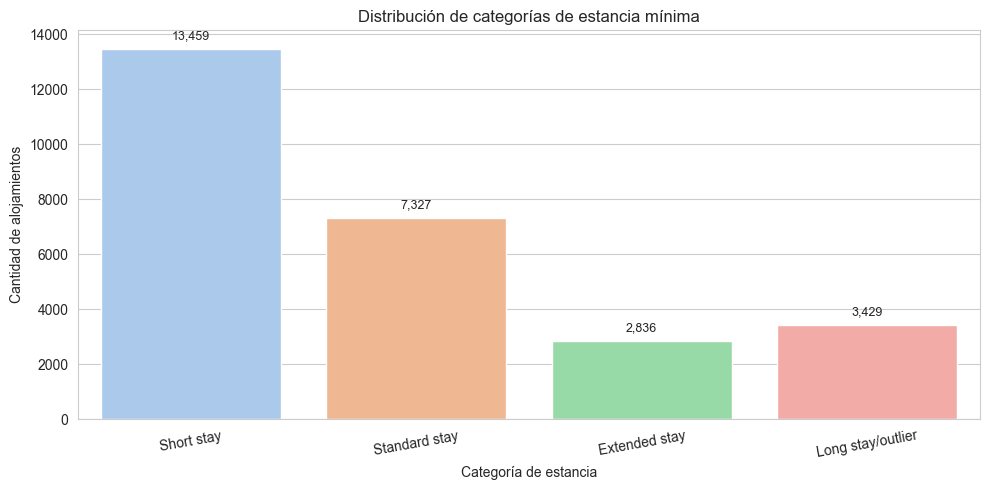

In [24]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=stay_counts.index, y=stay_counts.values, palette='pastel')
ax.set_title('Distribución de categorías de estancia mínima')
ax.set_xlabel('Categoría de estancia')
ax.set_ylabel('Cantidad de alojamientos')
plt.xticks(rotation=10)

for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{int(height):,}',
                (patch.get_x() + patch.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9, xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Interpretación

La mayoría de los alojamientos se concentra en categorías de estancia corta o estándar, mientras que una menor proporción exige estancias más largas. Este hallazgo es consistente con el análisis de outliers en `minimum_nights` y refuerza la utilidad de crear una variable categórica para distinguir comportamientos normales de políticas más restrictivas. Desde el punto de vista del negocio, esta segmentación ayuda a diferenciar alojamientos orientados a turismo corto frente a estancias prolongadas.

## Conclusiones finales del EDA

### Inconsistencias detectadas

- **Listings — `price` nulo:** hay anuncios sin precio; no es imputable de forma fiable y esas filas deben excluirse del análisis o de la capa transformada.
- **Listings — `last_review` y `reviews_per_month`:** comparten el mismo patrón de nulos; donde falta uno suele faltar el otro. Conviene completar o recalcular desde **Reviews** y descartar lo que siga incompleto si no aporta negocio.
- **Listings — `host_name` ausente:** pocos registros sin nombre de anfitrión; conviene un valor sustituto explícito para no mezclar nulos con texto en reportes.
- **Listings — `number_of_reviews` vs conteo real en Reviews:** el valor agregado en el anuncio puede no coincidir con el número de filas en `Reviews` por corte temporal, snapshots o reglas de la plataforma; la transformación debe alinear ambas fuentes con una regla explícita (ver abajo).
- **Listings — valores extremos:** `price`, `minimum_nights` y en menor medida otras numéricas presentan colas pesadas y outliers por IQR; no son errores automáticos, pero motivan **categorías** o tratamiento aparte en modelos.
- **Reviews / Calendar — escala y granularidad:** Reviews está a nivel reseña y Calendar a nivel día × listing; cualquier métrica global debe documentar si se agrega, filtra por fechas o se deja en detalle.

### Correlaciones relevantes

- Este EDA se centró en **calidad, distribuciones y outliers**, no en una matriz de correlación entre todas las variables numéricas.
- La relación estructural más importante es **`listing_id` / `id`** entre colecciones: permite unir Listings con Reviews y Calendar para métricas de actividad, disponibilidad y coherencia de conteos.
- Las variables de **fecha** (`last_review`, fechas en Reviews, `date` en Calendar) habilitan estudios temporales y estacionalidad una vez homogeneizadas en la fase de transformación.
- Si el curso o el modelo lo requieren, se puede añadir un bloque dedicado (por ejemplo correlación de Spearman/Pearson en Listings ya limpios) sobre `price`, `availability_365`, `number_of_reviews`, etc.

### Decisiones y transformaciones definidas por Colección

**Listings**

- **Eliminar** registros con `price` nulo.
- **`last_review` y `reviews_per_month`:** obtener o recalcular desde **Reviews** (última fecha y promedio mensual por listing); **eliminar** filas que sigan con nulos en esos campos si no se justifica su retención.
- **`host_name` nulo:** imputar literal `empty_hostname` (o equivalente acordado) para análisis y agrupaciones.
- **Variables derivadas por cuantiles (EDA):** `price_category`, `stay_category` (desde `minimum_nights`), `availability_category` (desde `availability_365`), según los cortes documentados en la interpretación de outliers.
- **`number_of_reviews` alineado con Reviews:** para cada listing, calcular el conteo de reseñas en la colección Reviews. Regla propuesta:
  - Si en tabla `number_of_reviews == 0` y el conteo calculado es distinto de 0, **asignar el conteo calculado**.
  - Si el valor en tabla es **mayor** que el conteo calculado, **no cambiar** (mantener el valor de tabla).
  - Si el valor en tabla es **menor** que el conteo calculado, **conservar el valor de tabla** (no sustituir por el conteo mayor; la tabla prevalece frente al agregado cuando el anuncio ya trae un número positivo).
  - En conjunto: con valor en tabla **> 0** se mantiene siempre el dato del listing; con **0** se puede actualizar desde el conteo cuando este demuestre reseñas existentes.
- **Formato y limpieza numérica:** validar `price` (y otras columnas) según el análisis de formato y de valores negativos; en los datos actuales el precio ya aparece como numérico, pero la regla sirve si el origen cambia.

**Reviews**

- Actúa como **fuente de verdad** para fechas de reseña y para el **conteo por listing** usado en la regla de `number_of_reviews` y en la imputación de `last_review` / `reviews_per_month`.
- Mantener la trazabilidad por `listing_id` (y `_id` de reseña) al agregar o filtrar; revisar duplicados y outliers según los resultados de las celdas de calidad.

**Calendar**

- Datos **diarios y voluminosos**; las transformaciones típicas pasan por agregaciones (por mes, semana o listing) o filtros de ventana temporal según el uso (ocupación, estacionalidad).
- Validar **`minimum_nights` y `maximum_nights`** (incluido el análisis de valores negativos); reglas de negocio pueden acotar rangos o marcar fechas anómalas.
- Cruzar con Listings por `listing_id` para enriquecer análisis de disponibilidad frente a precio y categorías definidas en Listings.

### Nota sobre validación posterior a las transformaciones

Tras aplicar las transformaciones acordadas (limpieza, imputaciones, reglas de negocio, derivación de variables, agregaciones, etc.), **conviene volver a ejecutar parte de las validaciones de este EDA** sobre los datos resultantes para **comprobar la efectividad** de los cambios. En la práctica eso puede incluir, según lo transformado: conteo de nulos por columna, duplicados, comprobación de rangos y valores negativos, coherencia entre colecciones (por ejemplo `number_of_reviews` vs Reviews, o fechas imputadas), y revisión de distribuciones u outliers en variables clave. El objetivo es confirmar que las reglas se aplicaron bien y que no aparecieron efectos secundarios (pérdida excesiva de filas, nuevos nulos, valores fuera de dominio).
